In [1]:
from langgraph.graph import StateGraph,START,END
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from dotenv import load_dotenv
import os

e:\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langgraph.graph import StateGraph,START,END
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

True

In [4]:
store=InMemoryStore()

In [5]:
user_id="user_432"

In [6]:
user_details=("user",user_id,"details")

store.put(user_details, "profile_1", {"data": "Name: Sajid"})
store.put(user_details, "profile_2", {"data": "Profession: Learning AI from YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "build University Management System"})

In [7]:
SYSTEM_PROMPT_TEMPLATE="""
You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Sajid...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [15]:
llm = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen1.5-1.8B-Chat",
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"),
))

# from langchain_google_genai import ChatGoogleGenerativeAI

# llm=ChatGoogleGenerativeAI(
#     api_key=os.getenv("GEMINI_API_KEY"),
#     model="gemini-2.5-flash"
# )

In [9]:
from typing import TypedDict
class MessagesState(TypedDict):
    messages: list[HumanMessage | AIMessage | SystemMessage]
    
    

In [17]:
from langchain_core.runnables import RunnableConfig
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)
    print("fetched :: ",len(items))
    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)
    prompt=[system_msg] + state["messages"]
    response = llm.invoke(prompt, config=config)
    return {"messages": [response]}

In [18]:
builder=StateGraph(MessagesState)
builder.add_node("chat", lambda state, config: chat_node(state, config, store))

# adding edges
builder.add_edge(START,"chat")
builder.add_edge("chat",END)

In [19]:
graph=builder.compile(store=store)

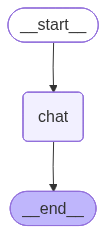

In [20]:
graph

In [23]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "user_432"}}

result = graph.invoke(
    {"messages": [HumanMessage(content="Tell me about myself")]},
    config,
)

print(result["messages"][-1].content)

fetched ::  5
Hello Sajid! It's great to meet you and learn more about your interests in learning AI from YouTube. As an AI language model, I can provide you with some personalized information and assistance based on the knowledge I have gathered about you.

1. Personal Profile:
Sajid is an individual who has a strong interest in artificial intelligence and its applications. He enjoys watching videos and tutorials on YouTube to gain insights into various techniques and algorithms used in machine learning, deep learning, and data science. His primary focus lies in building university management systems using Python as the programming language.

2. Skills and Tools:
Based on his preferred tools and framework for building university management systems, here are three relevant questions:

a) What specific programming languages and libraries do you frequently use in your university management system development? Could you provide some examples of these technologies and how they contribute t